<a href="https://colab.research.google.com/github/vishakhacodes/Capstone_Experiments_DeepLearning/blob/main/Experiment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Name= Vishakha Gaur

### Roll No= 2501940065

---

### EXPERIMENT 1 (FNN)

---

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8151 - loss: 0.3938 - val_accuracy: 0.8394 - val_loss: 0.3411
Epoch 2/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8388 - loss: 0.3493 - val_accuracy: 0.8409 - val_loss: 0.3347
Epoch 3/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8454 - loss: 0.3370 - val_accuracy: 0.8430 - val_loss: 0.3285
Epoch 4/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8497 - loss: 0.3280 - val_accuracy: 0.8441 - val_loss: 0.3278
Epoch 5/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8493 - loss: 0.3258 - val_accuracy: 0.8462 - val_loss: 0.3257
Epoch 6/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8502 - loss: 0.3228 - val_accuracy: 0.8472 - val_loss: 0.3240
Epoch 7/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8504 - loss: 0.3219 - val_accuracy: 0.8477 - val_loss: 0.3227
Epoch 8/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8534 - loss: 0.3179 - val_accuracy: 0.

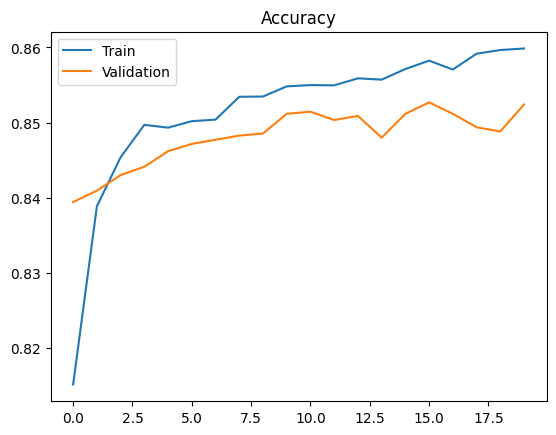

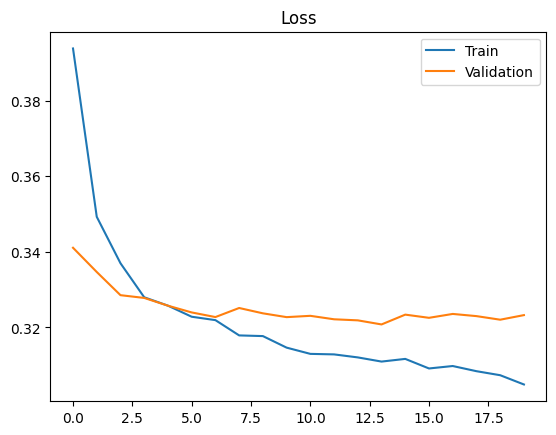

In [ ]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ==============================
# 2. LOAD DATASET
# ==============================
data = fetch_openml(name='adult', version=2, as_frame=True)
df = data.frame

# ==============================
# 3. DATA PREPROCESSING
# ==============================

# Remove missing values
df = df.dropna()

# Split features and target
X = df.drop('class', axis=1)
y = df['class']

# Fix target (IMPORTANT)
y = y.astype(str)
y = y.map({'>50K':1, '<=50K':0})
y = y.astype(int)

# One-hot encoding
X = pd.get_dummies(X)

# Force numeric (FIX FOR YOUR ERROR)
X = X.astype(float)

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 4. BUILD MODEL
# ==============================
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# ==============================
# 5. COMPILE MODEL
# ==============================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==============================
# 6. TRAIN MODEL
# ==============================
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# ==============================
# 7. EVALUATE MODEL
# ==============================
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# ==============================
# 8. PLOT RESULTS
# ==============================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['Train', 'Validation'])
plt.show()